In [1]:


#importlib.reload(test_spf)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from galois import GF2
import tableau as ta

from gspf_ilp import generalised_spf_logical,generalised_spf_logical_heuristic
from spf_graphs import crazy_graph, sample_lost_nodes
from decoder_methods import create_graph_code

0.1
['X2*X7*X15']
o 15
short first ['X2*X7*X15']
logi_anti_commute_clean X3*Z7*Z8*Z9*Z10
x logical X3*X8*X16
z logical X4*X12*Z16
['X1*X9*X13']
o 13
short first ['X1*X9*X13']
logi_anti_commute_clean X3*Z6*Z7*Z8*Z9
x logical X2*X11*X16
z logical X5*X12*Z16
['X0*X9*X15']
o 15
short first ['X0*X9*X15']
logi_anti_commute_clean X4*Z8*Z9*Z10*Z11
x logical X0*X9*X16
z logical X4*X13*Z16
['X0*X8*X13']
o 13
short first ['X0*X8*X13']
logi_anti_commute_clean X3*X9*Z13
x logical X0*X10*X16
z logical X4*X12*Z16
['X2*X8*X14']
o 14
short first ['X2*X8*X14']
logi_anti_commute_clean X3*Z7*Z8*Z9*Z10
x logical X3*X9*X16
z logical X4*X13*Z16
['X1*X7*X10']
o 10
short first ['X1*X7*X10']
logi_anti_commute_clean X2*X9*Z10
x logical X2*X9*X16
z logical X4*X15*Z16
['X0*X6*X7*X8*X12']
o 12
short first ['X0*X6*X7*X8*X12']
logi_anti_commute_clean Z0*Z1*Z2*Z3
x logical X0*X9*X10*X11*X16
z logical X5*X13*Z16
['X2*X7*X12']
o 12
short first ['X2*X7*X12']
logi_anti_commute_clean X3*X9*Z12
x logical X3*X8*X16
z logical

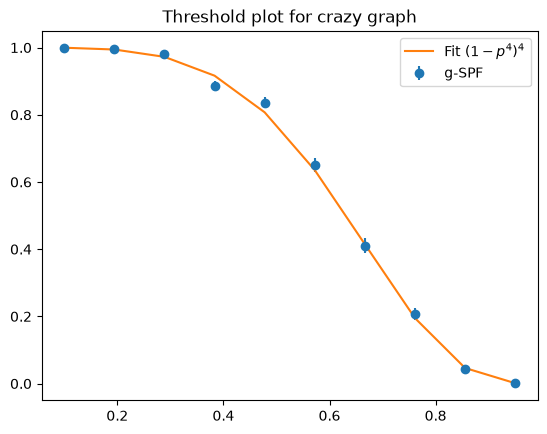

In [4]:
g = crazy_graph(4,4)
g = nx.to_numpy_array(g, dtype = np.uint16)
xlogi, zlogi, stabi = create_graph_code(g)
T = GF2(stabi)
numq = T.shape[1]//2
gg = 1
previous_meas = []
previous_meas = [ta.paulistring2tableau(ele, numq) for ele in previous_meas]

target = numq - 1          # output qubit O in tableau columns

# --- cache setup ---
cache = []                 # list of frozenset(support columns), full-tableau frame
max_cache = 1000

def pair_support(x, z, num_qubits, target_qubit):
    x = np.asarray(x).ravel().astype(int)
    z = np.asarray(z).ravel().astype(int)
    supp = set()
    for q in range(num_qubits):
        if q == target_qubit:
            continue
        if x[q] or x[q+num_qubits] or z[q] or z[q+num_qubits]:
            supp.add(q)
    if len(supp) == 0:
        return None          # supported only at O — valid success, not a cacheable pattern
    return frozenset(supp)
# -------------------

fail_list = []
fit = []
num_shots = 5_00

hits = 0
solves = 0

lost_prob = np.linspace(0.1, 0.95, 10)
for p in lost_prob:
    print(p)
    fail = 0

    for ele in range(num_shots):
        lq = sample_lost_nodes(g, p)
        lost_cols = [node - 1 for node in lq]
        lost_set = set(int(c) for c in lost_cols)

        # --- cache lookup: any stored pattern that avoids all lost qubits? ---
        hit = False

        for supp in cache:
            if lost_set.isdisjoint(supp):
                
                hit = True
                break

        if hit:
            hits += 1
            fail += 1                      # success (a valid pattern survives)
            continue
        # -------------------------------------------------------------------

        solves += 1
        res = generalised_spf_logical_heuristic(stabi,  lost_cols, target_qubit=target)
        if res["success"]:
            fail += 1
            # --- cache the found pattern (full-width x, z) ---
             
            supp = pair_support(res["x"], res["z"], numq, target)
            if supp is not None and supp not in cache:
                cache.append(supp)
                if len(cache) > max_cache:
                    cache.pop(0)         # FIFO eviction
            # ------------------------------------------------

    fail_list.append(fail/num_shots)
    fit.append((1-p**4)**4)

print(f"cache hits: {hits}, solves: {solves}, hit rate: {hits/(hits+solves):.3f}")

fail_list = np.asarray(fail_list)
yerr = np.sqrt(fail_list * (1 - fail_list) / num_shots)

plt.figure()
plt.title("Threshold plot for crazy graph")
plt.errorbar(lost_prob, fail_list, yerr=yerr, fmt="o", label="g-SPF")
plt.plot(lost_prob, fit, label=r"Fit $(1-p^{4})^{4}$")
plt.legend()
plt.show()

In [ ]:
fail_list = []
fit = []
num_shots = 500

lost_prob = np.linspace(0.1, 0.95, 10)
for p in lost_prob:
    print(p)
    fail = 0
    for ele in range(num_shots):
        lq = sample_lost_nodes(g, p)
        lost_cols = [node - 1 for node in lq]
        res = generalised_spf_logical_heuristic(stabi, lost_cols, target_qubit=numq-1)
        if res["success"]:
            fail += 1
    fail_list.append(fail/num_shots)
    fit.append((1-p**4)**4)

print(fail_list)

0.1
reduced_logicals [GF([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 1], order=2), GF([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
    0, 0, 0], order=2), GF([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
    0, 0, 0], order=2)]
reduced_logicals [GF([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 0, 0, 0, 0, 0], order=2), GF([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
  

KeyboardInterrupt: 